# Examples of control systems in frequency domain

## Libraries

In [1]:
# Install the control library if running in Colab
try:
    import control
except ImportError:
    !pip install control

import numpy as np
import scipy as sp
import control as ct
import matplotlib.pyplot as plt

## Plants

A set of plants are defined here using $\text{tf(num, den)}$ function of $\texttt{control}$ library, and investigated in the following sections.

$$G_1(s) = \frac{1}{s^2 + 2 s + 10} = \frac{1}{(s + (1+3j))(s + (1-3j))}$$
$$G_2(s) = \frac{1}{s^2 +   s - 2 } = \frac{1}{(s - 1)(s + 2)}$$
$$G_3(s) = \dots \text{todo: describe Padé approximation}$$
$$G_4(s) = \frac{-s + 2}{s^2 + 2 s + 10}$$

$G_1$ is stable, $G_2$ is unstable as it has a pole in $s = 1$, $G_3$ has a time delay (or its Padé approximation), $G_4$ has non-minimal phase.

In [2]:
# Define a collection of plants to test
plants = {
    "stable": ct.tf([1], [1, 2, 10]),                   # Standard 2nd order
    "unstable": ct.tf([1], [1, 1, -2]),                # Pole at s=2
    "with_delay": ct.tf([1], [1, 2, 10]) * ct.tf(*ct.pade(0.5, n=2)), # 0.5s delay
    "non_minimal_phase": ct.tf([-1, 2], [1, 2, 10]),    # RHP zero at s=2
}


### Example 1. Stable system

The forced response of the system in Laplace domain 

$$x(s) = \frac{1}{s^2 + 2 s + 10} u(s) \ ,$$


has a realization in time domain as

$$\ddot{x}(t) + 2 \dot{x}(t) + 10 x(t) = u(t) \ ,$$

It can be interpreted as a mass-damper-spring system, i.e. a LTI second order system with positive mass, damping coefficient and spring stiffness.

In [3]:
plant_name = "stable" 
G = plants[plant_name]
print(f"Investigating {plant_name} plant:\nG(s) = {G}")

Investigating stable plant:
G(s) = 
      1
--------------
s^2 + 2 s + 10



Phase Margin: inf° at nan rad/s
Gain Margin: inf at nan rad/s


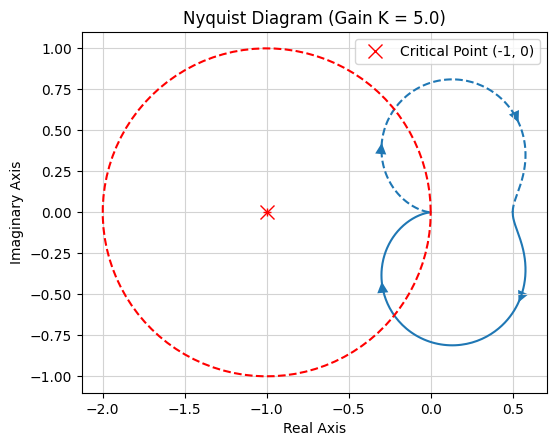

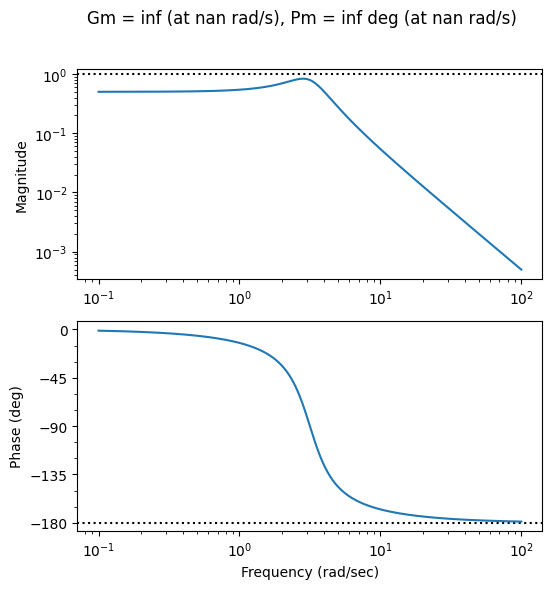

In [4]:
K = 5.0  # Regulator Gain
L = K * G

# Calculate Stability Margins
gm, pm, wg, wp = ct.margin(L)

# Plotting
fig, ax = plt.subplots(1,1, figsize=(6, 6))
ct.nyquist_plot(L)

theta_v = np.linspace(0, 2*np.pi, 100)
x_circle = -1 + np.cos(theta_v)
y_circle =      np.sin(theta_v)

# Aesthetics and Labels
ax.plot([-1], [0], 'rx', markersize=10, label='Critical Point (-1, 0)') # , fontweight='bold') # )
ax.plot(x_circle, y_circle, '--', color='red')
ax.set_title(f'Nyquist Diagram (Gain K = {K})')
ax.set_xlabel('Real Axis')
ax.set_ylabel('Imaginary Axis')
ax.grid(True)
ax.set_aspect("equal")
plt.legend()

fig, ax = plt.subplots(1,1, figsize=(6, 6))
ct.bode_plot(L, margins=True)
ax.grid(True)


print(f"Phase Margin: {pm:.2f}° at {wp:.2f} rad/s")
print(f"Gain Margin: {gm:.2f} at {wg:.2f} rad/s")
plt.show()

### Example 2. Unstable system

The forced response of the system in Laplace domain 

$$x(s) = \frac{1}{s^2 + s - 2} u(s) \ ,$$


has a realization in time domain as

$$\ddot{x}(t) + \dot{x}(t) - 2 x(t) = u(t) \ ,$$

i.e. it can be interpreted as the linearized equation of inverted-pendulum system around its unstable equilibrium,

$$m \ell^2 \ddot{\theta} + c \dot{\theta} - mg \ell \sin \theta = C(t) \ ,$$

with $\sin \theta \sim \theta$, for $\theta \approx \overline{\theta} = 0$. Thus the linearized equation reads

$$\ddot{\theta} + \frac{c}{m \ell^2} \dot{\theta} - \frac{g}{\ell} \theta = \frac{1}{m \ell^2} C(t) \ .$$

Investigating unstable plant:
G(s) = 
     1
-----------
s^2 + s - 2



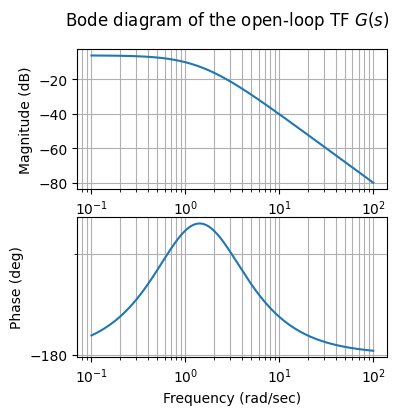

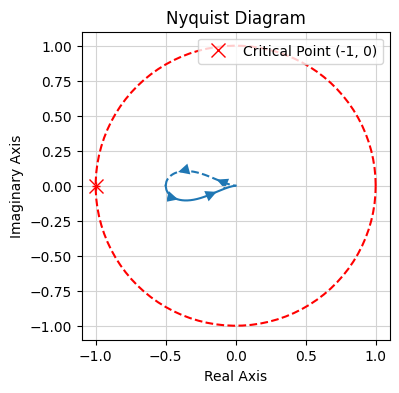

In [6]:
plant_name = "unstable" 
G = plants[plant_name]
print(f"Investigating {plant_name} plant:\nG(s) = {G}")

from control.matlab import bode

#> Bode diagram
fig, ax = plt.subplots(2,1, figsize=(4, 4))
mag, phase, omega = bode(G)
# ct.bode_plot(L, margins=True)
ax[0].plot(omega, mag)
ax[0].grid(True)
ax[1].plot(omega, phase)
ax[1].grid(True)
fig.suptitle(r"Bode diagram of the open-loop TF $G(s)$")

#> Nyquist diagram
fig, ax = plt.subplots(1,1, figsize=(4, 4))
ct.nyquist_plot(G)

theta_v = np.linspace(0, 2*np.pi, 100)
x_circle =      np.cos(theta_v)
y_circle =      np.sin(theta_v)

# Aesthetics and Labels
ax.plot([-1], [0], 'rx', markersize=10, label='Critical Point (-1, 0)') # , fontweight='bold') # )
ax.plot(x_circle, y_circle, '--', color='red')
ax.set_title(f'Nyquist Diagram')
ax.set_xlabel('Real Axis')
ax.set_ylabel('Imaginary Axis')
ax.grid(True)
ax.set_aspect("equal")
plt.legend()


In [120]:
k = 1.
zeros = [.2, .2]
poles = [10, 10]

K = k * ct.tf(np.poly(zeros), [1, 0, 0]) * ct.tf(1, np.poly(poles))

print(K)



  s^2 - 0.4 s + 0.04
----------------------
s^4 - 20 s^3 + 100 s^2



Regulator TF, K(s)=

 60 s + 6
----------
s^2 + 20 s

Phase Margin: 9.19 deg


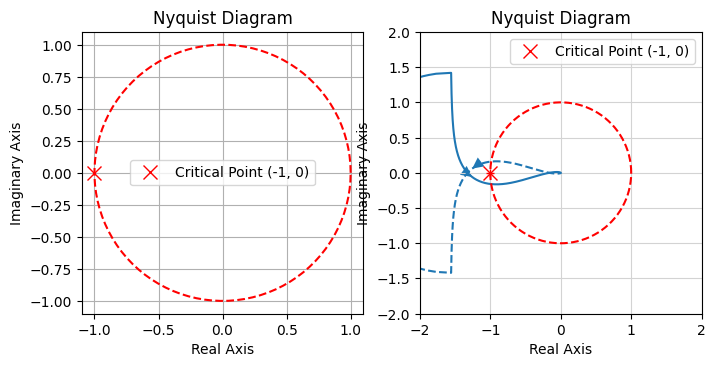

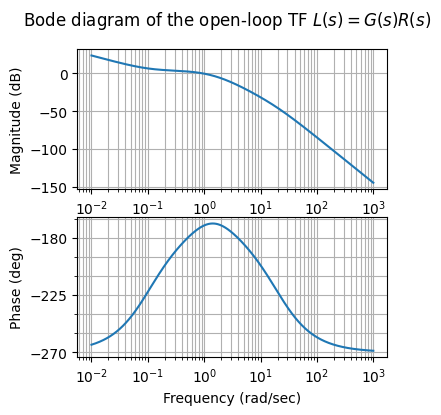

In [45]:


# k, z, p = -10., 1, 10
# K = ct.tf([1, z], [1, p, 0]) * k

#> Proportional controller
k = 3.
K = K

#> Controller with one integrator to get zero error for step input
k, z, p = .3, -.1, -20.
gain = k / (-z) * (-p)
K = ct.tf([1,-z],[1,-p, 0]) * gain

"""
#> Controller with double zeros and poles
zeros = [-.1, -.1]
poles = [-20.,-20.]
k = 1000
K = k * ct.tf(np.poly(zeros), [1, 0, 0]) * ct.tf(1, np.poly(poles))
"""

"""
#> With integral
k, z, p = 50., 1, -100
K = ct.tf([1], [1, -p]) * k

# print(K)

# 2. Design the Regulator
# We use two zeros at s=0.5 to 'pull' the phase up early
# and two high-frequency poles at s=20 to filter noise.
zeros = [-.2, -.2]
poles = [-20, -20]
k = 250 # High gain is usually needed to 'catch' the unstable system

K = k * ct.tf(np.poly(zeros), [1, 0, 0]) * ct.tf(1, np.poly(poles))
"""

print("Regulator TF, K(s)=")
print(K)

#> Open-loop TF
L = G * K

# 3. Check Stability
gm, pm, wg, wp = ct.margin(L)
print(f"Phase Margin: {pm:.2f} deg")

# Plotting
fig, ax = plt.subplots(1,2, figsize=(8, 4))
ct.nyquist_plot(L)

theta_v = np.linspace(0, 2*np.pi, 100)
x_circle =      np.cos(theta_v)
y_circle =      np.sin(theta_v)

# Aesthetics and Labels
ax[0].plot([-1], [0], 'rx', markersize=10, label='Critical Point (-1, 0)') # , fontweight='bold') # )
ax[0].plot(x_circle, y_circle, '--', color='red')
ax[0].set_title(f'Nyquist Diagram')
ax[0].set_xlabel('Real Axis')
ax[0].set_ylabel('Imaginary Axis')
ax[0].grid(True)
ax[0].set_aspect("equal")

ax[0].legend()

ax[1].plot([-1], [0], 'rx', markersize=10, label='Critical Point (-1, 0)') # , fontweight='bold') # )
ax[1].plot(x_circle, y_circle, '--', color='red')
ax[1].set_title(f'Nyquist Diagram')
ax[1].set_xlabel('Real Axis')
ax[1].set_ylabel('Imaginary Axis')
ax[1].grid(True)
ax[1].set_xlim(-2,2)
ax[1].set_ylim(-2,2)
ax[1].set_aspect("equal")

ax[1].legend()

from control.matlab import bode

fig, ax = plt.subplots(2,1, figsize=(4, 4))
mag, phase, omega = bode(L)
# ct.bode_plot(L, margins=True)
ax[0].plot(omega, mag)
ax[0].grid(True)
ax[1].plot(omega, phase)
ax[1].grid(True)
fig.suptitle(r"Bode diagram of the open-loop TF $L(s) = G(s)R(s)$")

plt.show()

#> Closed-loop TFs
Ly_ref = L / ( 1 + L )   # yref to y
Le_ref = 1 / ( 1 + L )   # yref to e

# fig, ax = plt.subplots(1,1, figsize=(5, 5))
# ct.bode_plot(1/(1+L), margins=True)
# ax.grid(True)

# print(f"Phase Margin: {pm:.2f}° at {wp:.2f} rad/s")
# print(f"Gain Margin: {gm:.2f} at {wg:.2f} rad/s")
# plt.show()



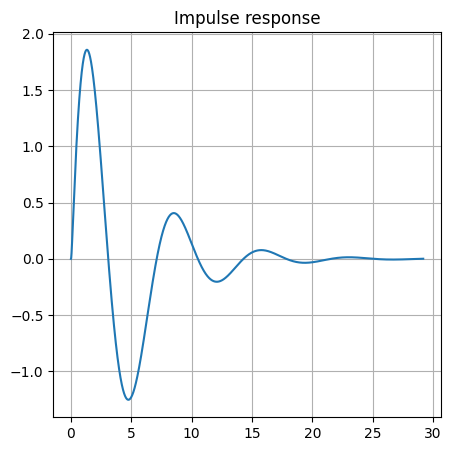

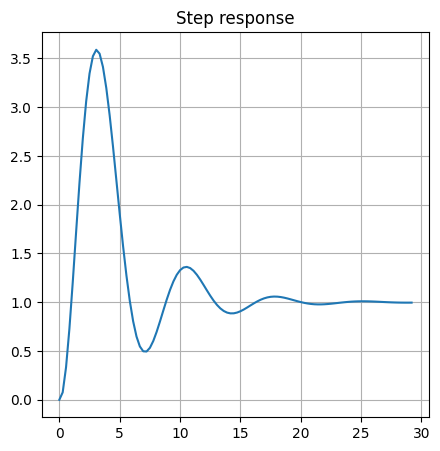

In [40]:
#> Impulse response
t, y = ct.impulse_response(L/(1+L),)

fig, ax = plt.subplots(1,1, figsize=(5,5))
ax.plot(t,y)
ax.grid(True)
ax.set_title("Impulse response")
plt.show()

#> Step response
t, y = ct.step_response(L/(1+L),)

fig, ax = plt.subplots(1,1, figsize=(5,5))
ax.plot(t,y)
ax.grid(True)
ax.set_title("Step response")
plt.show()

Text(0.5, 0.98, 'Bode diagram of the open-loop TF $L/(1+L)$')

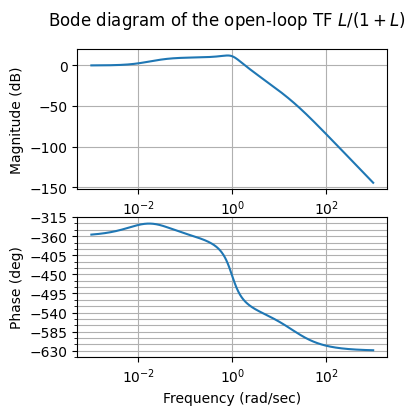

In [33]:
fig, ax = plt.subplots(2,1, figsize=(4, 4))
mag, phase, omega = bode(Ly_ref)
# ct.bode_plot(L, margins=True)
ax[0].plot(omega, mag)
ax[0].grid(True)
ax[1].plot(omega, phase)
ax[1].grid(True)
fig.suptitle(r"Bode diagram of the open-loop TF $L/(1+L)$")


Text(0.5, 0.98, 'Bode diagram of the open-loop TF $1/(1+L)$')

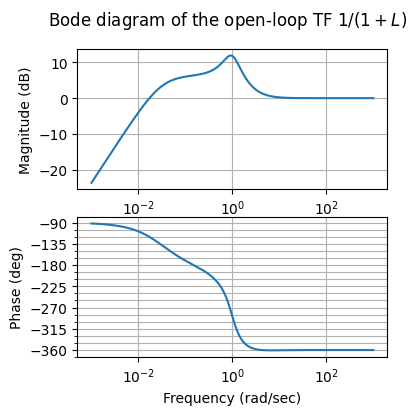

In [34]:
fig, ax = plt.subplots(2,1, figsize=(4, 4))
mag, phase, omega = bode(Le_ref)
# ct.bode_plot(L, margins=True)
ax[0].plot(omega, mag)
ax[0].grid(True)
ax[1].plot(omega, phase)
ax[1].grid(True)
fig.suptitle(r"Bode diagram of the open-loop TF $1/(1+L)$")

### Example 3.

### Example 4.